In [1016]:
#This cell is for importing required libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error
import seaborn as sns

In [1017]:
#This cell loads the files.
pgcb_df = pd.read_excel('data/PGCB_date_power_demand.xlsx')
econ_df = pd.read_csv('data/economic_full_1.csv')
weather_df = pd.read_excel('data/weather_data.xlsx',skiprows=3)

In [1018]:
#For structered timeline,Sort Chronologically and remove Duplicates.
pgcb_df['datetime'] = pd.to_datetime(pgcb_df['datetime'])
pgcb_df = pgcb_df.sort_values('datetime').drop_duplicates('datetime')

In [1019]:
#This creates a continuous hourly data. 
full_range = pd.date_range(start=pgcb_df['datetime'].min(), end=pgcb_df['datetime'].max(), freq='h')
pgcb_df = pgcb_df.set_index('datetime').reindex(full_range).rename_axis('datetime').reset_index()

In [1020]:
#Identifies outliers and marks them NaN using Simple Rolling Median Method.
rolling_median_p = pgcb_df['demand_mw'].rolling(window=7, center=True).median()
rolling_mad_p = pgcb_df['demand_mw'].rolling(window=7, center=True).apply(
    lambda x: np.median(np.abs(x - np.median(x)))
)
outliers_p = np.abs(pgcb_df['demand_mw'] - rolling_median_p) > (3 * 1.4826 * rolling_mad_p)
pgcb_df.loc[outliers_p, 'demand_mw'] = np.nan

In [1021]:
#I used simple Linear interpolation upto 6 hrs in this cell.
pgcb_df['demand_mw'] = pgcb_df['demand_mw'].interpolate(method='linear', limit=6)

In [1022]:
#Renamed cols and sorted the weather chronologically also removed duplicates.
weather_df = weather_df.rename(columns={
    col: 'apparent_temp' for col in weather_df.columns if 'apparent_temperature' in col
})
weather_df = weather_df.rename(columns={
    col: 'humidity' for col in weather_df.columns if 'humidity' in col.lower()
})
weather_df['datetime'] = pd.to_datetime(weather_df['time']).dt.tz_localize(None)
weather_df = weather_df.sort_values('datetime').drop_duplicates('datetime')
weather_features = ['apparent_temp', 'humidity']

In [1023]:
#Made the weather data hourly continuous and reindexed it.
weather_df = weather_df.set_index('datetime').reindex(full_range).rename_axis('datetime').reset_index()

In [1024]:
#Identifies outliers and marks them NaN using Simple Rolling Median Method also using interpolation.
for feat in weather_features:
    rolling_median = weather_df[feat].rolling(window=6, center=True).median() 
    rolling_mad = weather_df[feat].rolling(window=6, center=True).apply(
        lambda x: np.median(np.abs(x - np.median(x)))
    )
    outliers = np.abs(weather_df[feat] - rolling_median) > (3 * 1.4826 * rolling_mad)
    weather_df.loc[outliers, feat] = np.nan
    weather_df[feat] = weather_df[feat].interpolate(method='linear', limit=6)

In [1025]:
#I selected the following features from economy.
selected_econ = [
    'Urban population', 
    'Industry (including construction), value added (% of GDP)',
    'Manufacturing, value added (% of GDP)',
    'GDP growth (annual %)',
    'Computer, communications and other services (% of commercial service exports)',
    'GDP (current US$)', 
    'Population, total',
    'Access to electricity (% of population)',
    'Foreign direct investment, net inflows (% of GDP)'
]

In [1026]:
#Selected the economies rows and year columns for data reshaping .
econ_filtered = econ_df[econ_df['Indicator Name'].isin(selected_econ)]
year_cols = [col for col in econ_filtered.columns if col.isdigit()]

In [1027]:
#Data reshaping.
econ_long = econ_filtered.melt(id_vars=['Indicator Name'], value_vars=year_cols, 
                               var_name='year', value_name='val')
econ_pivot = econ_long.pivot(index='year', columns='Indicator Name', values='val').reset_index()
econ_pivot['year'] = econ_pivot['year'].astype(int)

In [1028]:
#Filled if any data was missing in economy.
econ_pivot = econ_pivot.ffill()

In [1029]:
#Merge the data.
pgcb_df['year'] = pgcb_df['datetime'].dt.year
df = pgcb_df.merge(econ_pivot, on='year', how='left')
df = df.merge(weather_df[['datetime', 'apparent_temp','humidity']], on='datetime', how='left')

In [1030]:
#Feature Enginneering 
df['hour_sin'] = np.sin(2 * np.pi * df['datetime'].dt.hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['datetime'].dt.hour / 24)
df['month_sin'] = np.sin(2 * np.pi * df['datetime'].dt.month / 12)
df['month_cos'] = np.cos(2 * np.pi * df['datetime'].dt.month / 12)
df['day_of_week'] = df['datetime'].dt.dayofweek
df['temp_lag_24h'] = df['apparent_temp'].shift(24)
df['demand_change_1h'] = df['demand_mw'].shift(1) - df['demand_mw'].shift(2)
df['is_weekend'] = df['day_of_week'].isin([4, 5]).astype(int)

In [1031]:
#Shifted 1 hr ahead and calculated mean and std.
df['demand_lag_1h'] = df['demand_mw'].shift(1)
df['demand_lag_24h'] = df['demand_mw'].shift(24)
df['rolling_mean_6h'] = df['demand_mw'].shift(1).rolling(window=6).mean()
df['rolling_std_6h'] = df['demand_mw'].shift(1).rolling(window=6).std()

In [1032]:
#Created Target by shifting one hr back.
df['target'] = df['demand_mw'].shift(-1)

In [1033]:
#Final Features
features = ['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'day_of_week', 'is_weekend',
            'demand_lag_1h', 'demand_lag_24h', 'rolling_mean_6h', 'rolling_std_6h', 'temp_lag_24h','demand_change_1h',
            'apparent_temp', 'humidity'] + selected_econ

In [1034]:
#Dropping NaN Features.
df_final = df.dropna(subset=features + ['target']).reset_index(drop=True)

In [1035]:
#Defined the training and testing data sets.
train_df = df_final[df_final['datetime'] < '2024-01-01']
test_df = df_final[(df_final['datetime'] >= '2024-01-01') & (df_final['datetime'] < '2025-01-01')]

X_train, y_train = train_df[features], train_df['target']
X_test, y_test = test_df[features], test_df['target']

In [1036]:
#model selection.
import xgboost as xgb
model = xgb.XGBRegressor(
    n_estimators=1500, 
    learning_rate=0.05, 
    max_depth=6, 
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:absoluteerror', 
    random_state=42,
    early_stopping_rounds=50
)

In [1037]:
#model trainig.
model.fit(
    X_train, y_train, 
    eval_set=[(X_test, y_test)], 
    verbose=100
)

[0]	validation_0-mae:3445.13050
[100]	validation_0-mae:392.80808
[200]	validation_0-mae:321.41566
[300]	validation_0-mae:302.67561
[400]	validation_0-mae:294.20332
[500]	validation_0-mae:289.51689
[600]	validation_0-mae:286.69910
[700]	validation_0-mae:284.33586
[800]	validation_0-mae:282.41292
[900]	validation_0-mae:280.76232
[1000]	validation_0-mae:280.29023
[1100]	validation_0-mae:279.28679
[1170]	validation_0-mae:279.26370


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:absoluteerror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [1038]:
#Model prediction and MAPE.
y_pred = model.predict(X_test)
final_mape = mean_absolute_percentage_error(y_test, y_pred) * 100
print(f"Final Model MAPE (2024 Hold-out): {final_mape:.2f}%")

Final Model MAPE (2024 Hold-out): 2.46%


<Figure size 1000x800 with 0 Axes>

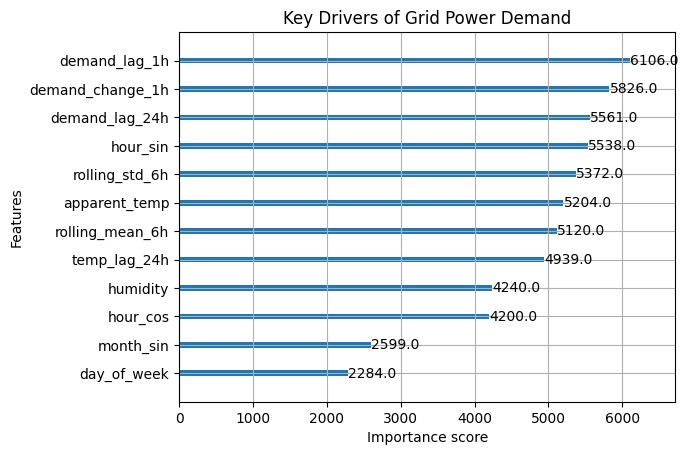

In [1039]:
plt.figure(figsize=(10, 8))
xgb.plot_importance(model, importance_type='weight', max_num_features=12, 
                   title="Key Drivers of Grid Power Demand")
plt.show()

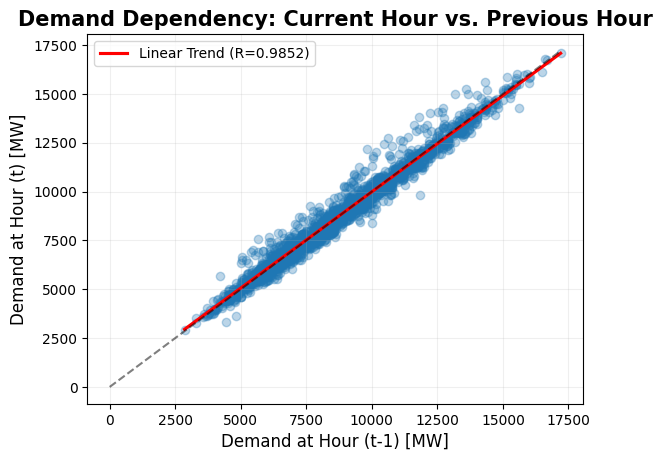

<Figure size 600x600 with 0 Axes>

In [1040]:
# This plot shows demand at t highly depends on demand at t-1.
df['demand_lag_1h'] = df['demand_mw'].shift(1)
correlation = df['demand_mw'].corr(df['demand_lag_1h'])
sns.regplot(data=df.sample(2000), x='demand_lag_1h', y='demand_mw', 
            scatter_kws={'alpha':0.3, 'color':'#1f77b4'}, 
            line_kws={'color':'red', 'label':f'Linear Trend (R={correlation:.4f})'})
plt.title('Demand Dependency: Current Hour vs. Previous Hour', fontsize=15, fontweight='bold')
plt.xlabel('Demand at Hour (t-1) [MW]', fontsize=12)
plt.ylabel('Demand at Hour (t) [MW]', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.2)
max_val = df['demand_mw'].max()
plt.plot([0, max_val], [0, max_val], color='black', linestyle='--', alpha=0.5, label='Perfect Persistence (y=x)')
plt.figure(figsize=(5, 5), dpi=120)
plt.tight_layout()
plt.show()

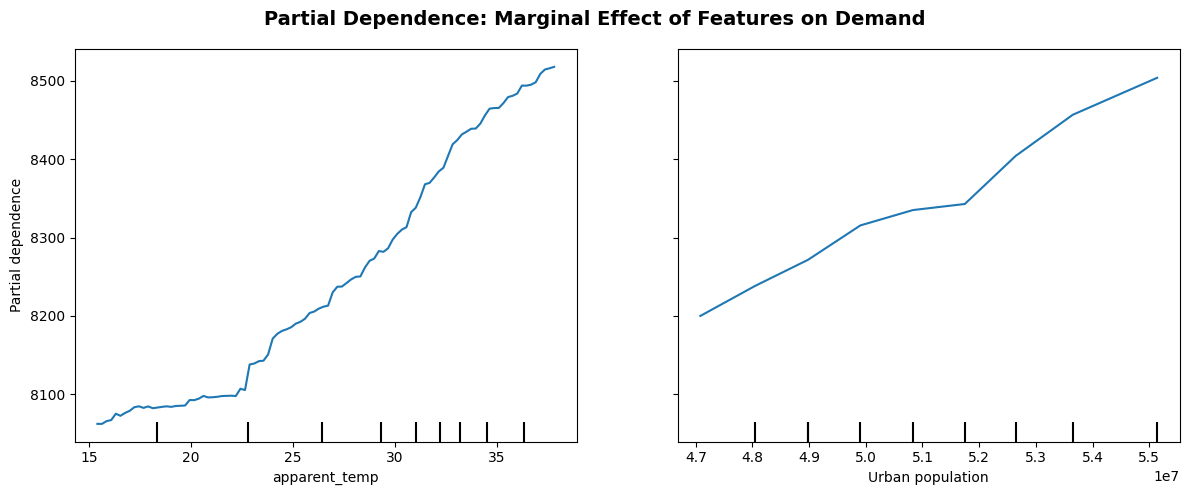

In [1041]:
# Showing here partial dependency of selected features on demand.
from sklearn.inspection import PartialDependenceDisplay
features_to_plot = ['apparent_temp', 'Urban population']
fig, ax = plt.subplots(figsize=(12, 5))
PartialDependenceDisplay.from_estimator(model, X_train, features_to_plot, ax=ax)
plt.suptitle('Partial Dependence: Marginal Effect of Features on Demand', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

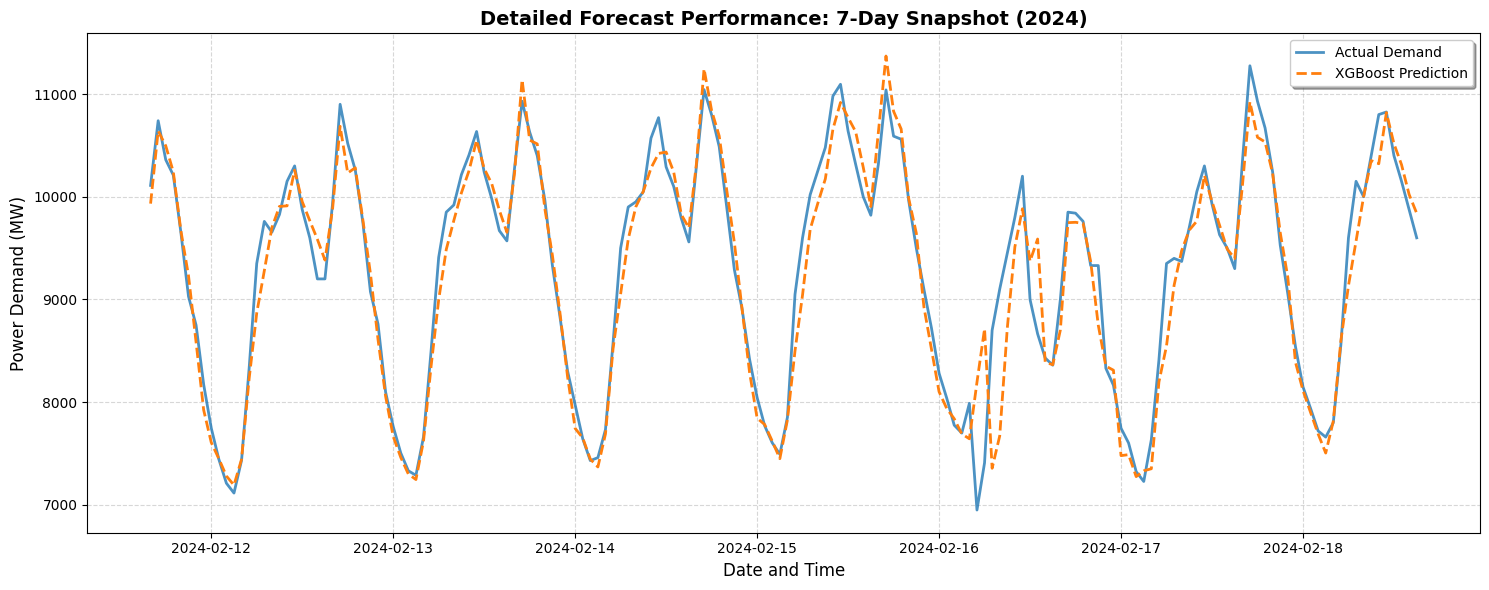

In [1042]:
# Selected a 1 week window to show actual demand and my model prediction.
start, end = 1000, 1168 
time_axis = test_df['datetime'].iloc[start:end]
actuals = y_test.iloc[start:end]
predictions = y_pred[start:end]
plt.figure(figsize=(15, 6), dpi=100)
plt.plot(time_axis, actuals, label='Actual Demand', color='#1f77b4', linewidth=2, alpha=0.8)
plt.plot(time_axis, predictions, label='XGBoost Prediction', color='#ff7f0e', linestyle='--', linewidth=2)
plt.title('Detailed Forecast Performance: 7-Day Snapshot (2024)', fontsize=14, fontweight='bold')
plt.xlabel('Date and Time', fontsize=12)
plt.ylabel('Power Demand (MW)', fontsize=12)
plt.legend(frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()